# ENTSO-E Price Spread Analysis: Day-Ahead vs Intraday (Spain Case Study) 📊

This notebook analyzes the price spread between Day-Ahead (DA) and Intraday (ID) auctions using the ENTSO-E API.

**Why Spain (ES)?** 
While the project target is Germany (DE_LU), German Intraday Auction prices are currently not published as a public time series on the ENTSO-E platform. **Spain** is used here as a representative European market where this data is available, allowing us to model the volatility and spread characteristics required for Phase 2 (Stochastic Optimization).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Add core_api/src to path
sys.path.append(os.path.join(os.getcwd(), "..", "core_api", "src"))

from data.entsoe_e_data_provider import ENTSOEPriceProvider

sns.set_theme(style="whitegrid")
load_dotenv("../.env")

API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    print("⚠️ ENTSOE_API_KEY not found in .env. Please set it or enter it manually below.")

## 1. Fetch Price Data

In [3]:
# Configuration - Using Spain (ES) for real Intraday Auction data
COUNTRY_CODE = "ES"
DAYS_TO_FETCH = 14 # Increased for better model fitting
end_date = datetime.now() - timedelta(days=1)
start_date = end_date - timedelta(days=DAYS_TO_FETCH)

provider = ENTSOEPriceProvider(api_key=API_KEY, country_code=COUNTRY_CODE)

print(f"Fetching data for {COUNTRY_CODE} from {start_date.date()} to {end_date.date()}...")

try:
    da_prices = provider.fetch_day_ahead_data(
        pd.Timestamp(start_date).tz_localize('UTC'), 
        pd.Timestamp(end_date).tz_localize('UTC')
    )
    id_prices = provider.fetch_intraday_data(
        pd.Timestamp(start_date).tz_localize('UTC'), 
        pd.Timestamp(end_date).tz_localize('UTC')
    )
    print(f"✅ Fetched {len(da_prices)} DA records and {len(id_prices)} ID records.")
except Exception as e:
    print(f"❌ Error fetching data: {e}")

Fetching data for ES from 2026-05-30 to 2026-06-13...
✅ Fetched 1344 DA records and 1344 ID records.


## 2. Preprocessing

In [4]:
if 'da_prices' in locals() and 'id_prices' in locals():
    df = pd.DataFrame({
        'price_da': da_prices,
        'price_id': id_prices
    }).dropna()

    CONVERSION_FACTOR = 1.05 / 1000.0
    df['price_da_usd'] = df['price_da'] * CONVERSION_FACTOR
    df['price_id_usd'] = df['price_id'] * CONVERSION_FACTOR

    df['spread_usd'] = df['price_id_usd'] - df['price_da_usd']
    df.index = df.index.tz_convert('Europe/Madrid')
    display(df.head())

,price_da,price_id,price_da_usd,price_id_usd,spread_usd
2026-05-30 22:30:00+02:00,117.79,122.45,0.12368,0.128573,0.004893
2026-05-30 22:45:00+02:00,111.59,114.41,0.11717,0.120131,0.002961
2026-05-30 23:00:00+02:00,111.20,116.03,0.11676,0.121832,0.005072
2026-05-30 23:15:00+02:00,109.00,111.59,0.11445,0.117170,0.002720
2026-05-30 23:30:00+02:00,111.20,114.00,0.11676,0.119700,0.002940


## 3. Visualization

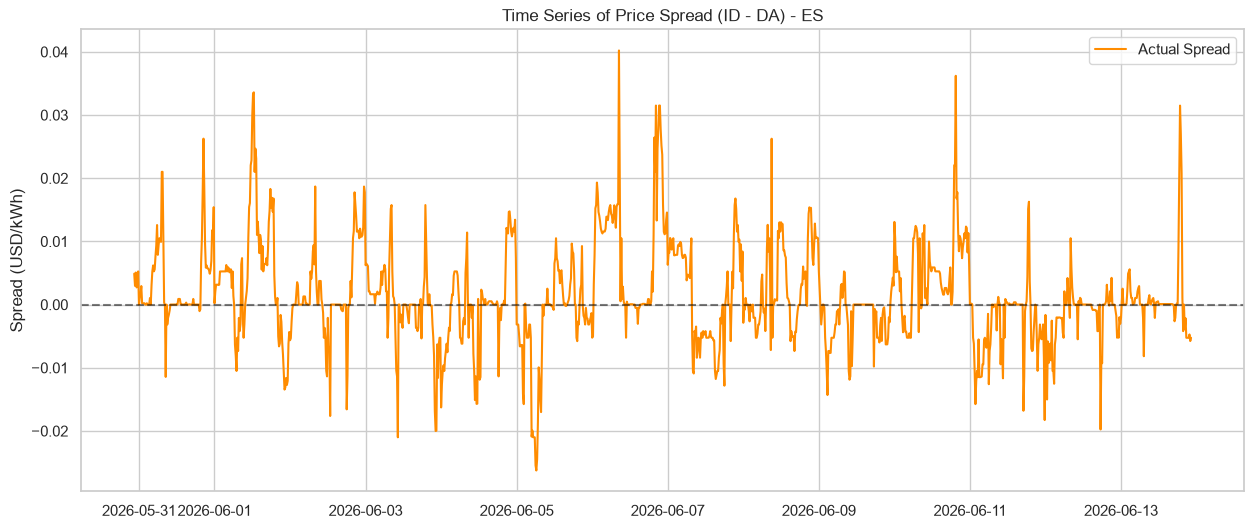

In [5]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['spread_usd'], color='darkorange', lw=1.5, label='Actual Spread')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title(f"Time Series of Price Spread (ID - DA) - {COUNTRY_CODE}")
plt.ylabel("Spread (USD/kWh)")
plt.legend()
plt.show()

## 4. Time Series Modeling 🧪

### Understanding GARCH Models
Energy prices and spreads often exhibit **Volatility Clustering**—periods of high variance followed by high variance, and low variance followed by low variance. Standard linear models (like ARMA) assume constant variance (**Homoskedasticity**), which fails to capture the "spikiness" of energy markets.

**GARCH** (Generalized Autoregressive Conditional Heteroskedasticity) models address this by modeling the variance itself as a time-dependent process.

#### The Components of our AR(1)-GARCH(1,1) Model:

1. **Mean Equation (AR1):** models the expected value of the spread based on its own past value.
   $$y_t = \mu + \phi y_{t-1} + \epsilon_t$$
   Where $\phi$ is the persistence of the spread level.

2. **Volatility Equation (GARCH 1,1):** models the variance (uncertainty) $\sigma_t^2$ of the error term $\epsilon_t$.
   $$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$
   *   $\omega$: Baseline constant variance.
   *   $\alpha$ (**ARCH term**): How the variance reacts to recent "shocks" (the squared error from the previous step).
   *   $\beta$ (**GARCH term**): How the variance persists over time (the "memory" of the volatility).

**Why this matters for Battery Optimization:**
In Phase 2 (Stochastic Optimization), we don't just care about the *average* spread. We care about the *risk* of price spikes. GARCH allows us to generate thousands of realistic "what-if" scenarios (paths) that reflect the true probability of extreme volatility, ensuring our battery strategy is robust against market shocks.

Energy spreads often exhibit **Volatility Clustering** (large spikes followed by more spikes). A standard Linear Model (like ARMA) won't capture the "spikiness." Instead, we use a **GARCH** (Generalized Autoregressive Conditional Heteroskedasticity) model.

We will model:
1. **Mean Equation (AR1):** Captures the positive bias and persistence.
2. **Volatility Equation (GARCH 1,1):** Captures the clustering of spikes.

In [7]:
try:
    from arch import arch_model
except ImportError:
    print("📦 Installing arch library...")
    !pip install arch --quiet
    from arch import arch_model

# Scale the spread slightly for better solver stability (GARCH likes returns/residuals around ~1-10 magnitude)
scale_factor = 100
scaled_spread = df['spread_usd'] * scale_factor

# Fit an AR(1)-GARCH(1,1) model
# mean='AR', lags=1 -> AR(1) mean
# vol='GARCH', p=1, q=1 -> GARCH(1,1) volatility
model = arch_model(scaled_spread, mean='AR', lags=1, vol='Garch', p=1, q=1, dist='Normal')
res = model.fit(disp='off')

print(res.summary())

                           AR - GARCH Model Results                           
Dep. Variable:             spread_usd   R-squared:                       0.727
Mean Model:                        AR   Adj. R-squared:                  0.727
Vol Model:                      GARCH   Log-Likelihood:               -484.568
Distribution:                  Normal   AIC:                           979.135
Method:            Maximum Likelihood   BIC:                           1005.15
                                        No. Observations:                 1343
Date:                Sun, Jun 14 2026   Df Residuals:                     1341
Time:                        20:18:03   Df Model:                            2
                                   Mean Model                                   
                    coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------------------------------------------------------------
Const         5.0801e-03  1.005e-02      0.506

### 4.1 Visualizing the Fit
We can look at the "Conditional Volatility" — this is the model's estimate of the spread uncertainty at each hour.

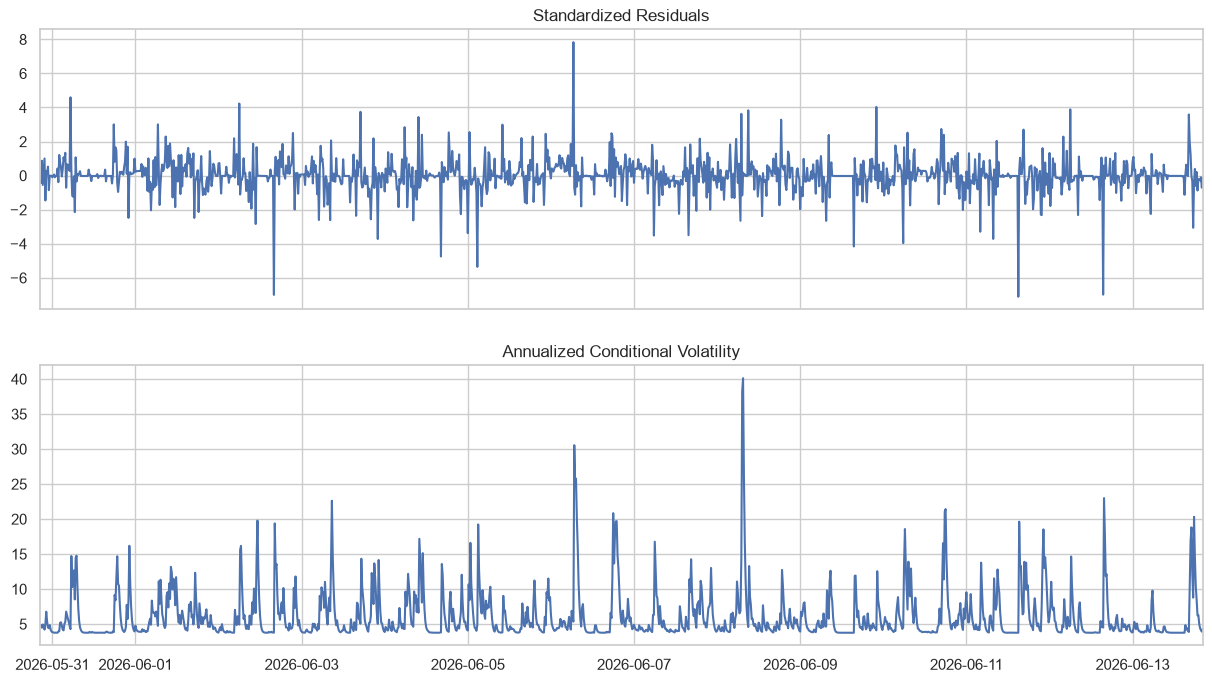

In [8]:
fig = res.plot(annualize='D')
fig.set_size_inches(15, 8)
plt.show()

### 4.2 Scenario Generation (The Quant Goal)
Now we can use the fitted parameters to generate **realistic stochastic scenarios**. These look much more like real market data than simple Gaussian noise.

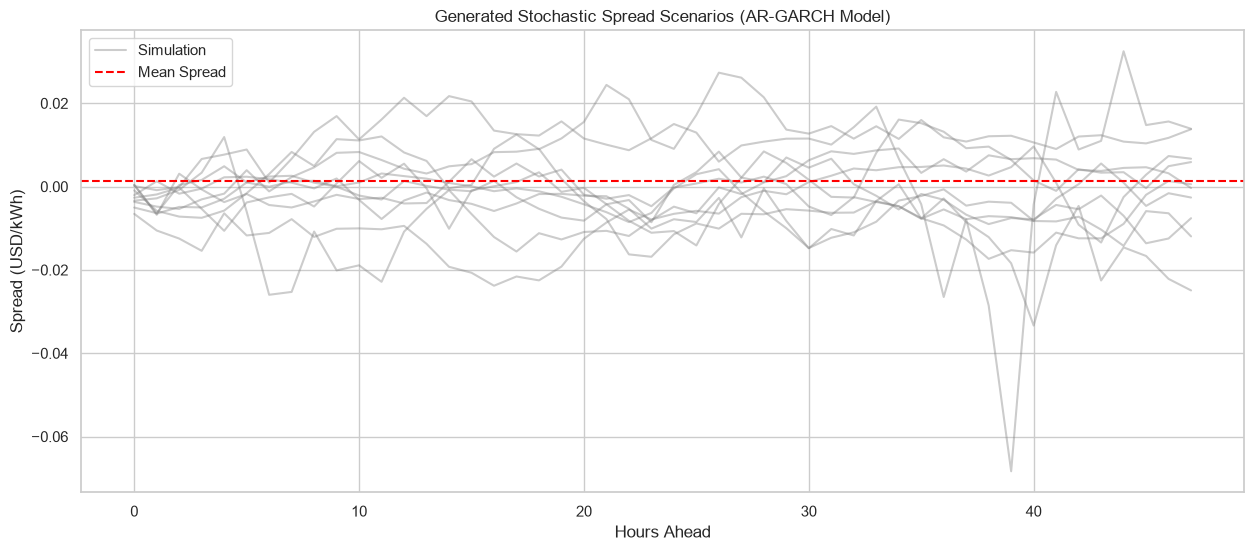

In [9]:
n_forecast = 48 # 2 days
n_sims = 10

forecasts = res.forecast(horizon=n_forecast, method='simulation', simulations=n_sims)
simulated_paths = forecasts.simulations.values[-1, :, :] / scale_factor # Rescale back

plt.figure(figsize=(15, 6))
for i in range(n_sims):
    plt.plot(simulated_paths[i, :], color='gray', alpha=0.4, label='Simulation' if i == 0 else "")

plt.axhline(df['spread_usd'].mean(), color='red', linestyle='--', label='Mean Spread')
plt.title(f"Generated Stochastic Spread Scenarios (AR-GARCH Model)")
plt.ylabel("Spread (USD/kWh)")
plt.xlabel("Hours Ahead")
plt.legend()
plt.show()

## 5. Key Takeaways for Phase 2

*   **GARCH Parameters:** The coefficients $\alpha$ (ARCH) and $\beta$ (GARCH) tell us how long a "spike" lasts. If $\beta$ is high (~0.8), high volatility persists.
*   **Fat Tails:** Notice how some simulated paths show massive spikes while others are quiet. This is exactly what the Stochastic Optimizer needs to build a robust battery plan.